
## Overfit Potential of Artificial Neural Networks and its diagnosis

#### Dursun Dashdamirov
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Gonzalez, Graduate Student, The University of Texas at Austin


### Executive Summary

Engineers often underestimate the overfit potential of Artificial Neural Networks and rely on simple metrics and validation performance, resulting in suboptimal models in real-life production environments. This notebook demonstrates how easy it is to overfit a Convolutional Neural Network to a CIFAR-10 dataset with 60000 images and 10 categories. Then, offers five effective methods to diagnose your model and understand what your model is actually learning. We recommend carrying out at least three of the diagnosis methods to ensure generalization.

# Getting Started

* To execute the provided codes Python 3.8+ should be installed in your system.
* The required libraries can be installed with following comand:
  
```bash
!pip install numpy matplotlib torch torchvision pytorch-grad-cam scikit-learn




### Importing necesary libraries

In [ ]:
!pip install -q numpy matplotlib torch torchvision torchinfo grad-cam scikit-learn

print("All the libraries are installed successfully!")

All the libraries are installed successfully!


In [ ]:
import numpy as np                          # Numerical operations
import matplotlib.pyplot as plt             # Visualization

import torch                                # Core PyTorch framework
import torch.nn as nn                       # Neural network module definitions (layers, Losses)
from torchvision import transforms          # Image transformations
from torch.utils.data import DataLoader,Subset  # Data batching, shuffling, and dataset slicing
from torchvision.datasets import CIFAR10    # Loader for CIFAR-10 dataset
import torch.nn.functional as F             # Functional interface for activations, convs, etc.
from torchinfo import summary               # Built-in model summary function


from pytorch_grad_cam import GradCAM        # Grad-CAM explanation method for CNNs
from pytorch_grad_cam.utils.image import show_cam_on_image  # Utility to overlay heatmaps on images from GRAD-CAM
from torch.utils.data import Dataset, DataLoader             # Base dataset class and loader

from sklearn.manifold import TSNE           # t-SNE dimensionality reduction


### Functions

Reusing code via the usage of functions is one of the best practices to ensure compact and readable code. Let's define commonly used ones across notebook:

In [ ]:
# Function to get subset of dataset
def get_subset(dataset, fraction=0.1):
    num_samples = int(len(dataset) * fraction)
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    return Subset(dataset, indices)

# Creating validation split from training data
def split_train_val(dataset, val_fraction=0.2):

    """Split dataset into train and validation and returns them as Subset object"""
    total = len(dataset)
    val_size = int(total * val_fraction)
    train_size = total - val_size

    indices = np.random.permutation(total)
    train_indices = indices[train_size:]
    val_indices = indices[:val_size]

    return Subset(dataset, train_indices), Subset(dataset, val_indices)

def evaluate_model(model, test_loader, device):
    """Evaluates model on test set and returns accuracy value"""
    model.eval()
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_acc = 100 * test_correct / test_total
    print(f'Final Test Accuracy: {test_acc:.2f}%')

    return test_acc

The workflow consists of 2 main parts:
1. **Training of CNN.** Explains general workflow of data handling and model building with Pytorch. Also demonstrates how easy it is to overfit a simple CNN model to 50000 data instances.
2. **Model Diagnosis Methods.** Demonstration of 5 effective ways to understand your CNN model.

# 1. Training of CNN

Convolutional Neural Networks are are a specialized class of deep neural networks designed for processing grid-structured data, such as images.

1. Each training session starts by loading/preparing of data, which enables the data to be split into batches and be processed faster.
2. **Defining the architecture.** The initial model is built where we define the number and depth of layers, kernel size (dimensions of the filter, e.g., 3x3), and padding (adding border pixels to control output size), etc.
3. Train and evaluate the model
4. Repeat to update hyperparameters

Outside of this loop, there is one component that is over looked --> The model diagnosis. It's common practice to evaluate models with a single confusion matrix without having an idea of what the model learned. The next section will discuss this, but for now, let's train our model

### Loading data

In [ ]:
# CIFAR-10 with normalization values
transform = transforms.Compose([transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])])

# Download and load CIFAR-10
train_dataset_full = CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset_full = CIFAR10(root='./data', train=False, download=True, transform=transform)

The notebook uses CIFAR-10 dataset [1] which consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

### Preparing data for training

In [ ]:
# Split into train/val
val_dataset_full, train_dataset_remaining = split_train_val(train_dataset_full, val_fraction=0.2)

# Create subsets for faster experimentation
val_dataset = get_subset(val_dataset_full, fraction=0.5)  # 50% of val
test_dataset = get_subset(test_dataset_full, fraction=0.1)  # 10% of test

# Create loaders
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

# Defining classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(class_names)

# Printing information about loaded data
print(f"Dataset: CIFAR-10")
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Image size: 32x32 (CIFAR-10 native resolution)")
print(f"Full training samples: {len(train_dataset_full)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"\n CIFAR-10 loaded, We are ready to train!")

Dataset: CIFAR-10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10
Image size: 32x32 (CIFAR-10 native resolution)
Full training samples: 50000
Validation samples: 5000
Test samples: 1000

 CIFAR-10 loaded, We are ready to train!


 It is highly recommended to use a GPU for image data as parallelization offers a critical boost in speed. The device that Pytorch will use should be defined explicitly:

In [ ]:
# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


### Defining our architecture

The next step is to construct our model architecture. In this step, we decide on the number of layers, the width of each layer, the size of the convolutional matrices, etc. At the first loop of your modelling process, almost all of the mentioned parameters can be considered as potential hyperparameters, meaning that several iterations are needed to construct an optimal architecture.

But here are 5 terms and rules of thumb that you need to understand for building CNNs are:


1. **Convolution** – a sliding filter that detects local patterns (edges, textures) in an image. You typically increase the number of filters as depth increases to learn complex features.
2. **Stride** – how many pixels the filter moves each step; a stride of 1 preserves detail, stride >1 reduces spatial resolution and speeds up computation.
3. **Padding** – adding pixels (usually zeros) around the input to control output size.
4. **ReLU Activation** – a non-linear function (`max(0, x)`) applied after convolution layers; it helps the model learn complex relationships.
5. **Pooling** – a downsampling operation (e.g., taking the max in each 2×2 region) used to reduce spatial size while retaining important information. It helps prevent overfitting and lowers computation.


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # For 32×32 images: 32 - 16 - 8 - 4 - 2
        self.fc1 = nn.Linear(512 * 2 * 2, 2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 32 - 16
        x = self.pool(F.relu(self.conv2(x)))  # 16 - 8
        x = self.pool(F.relu(self.conv3(x)))  # 8 - 4
        x = self.pool(F.relu(self.conv4(x)))  # 4 - 2

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

**Our model's structure**
- **Conv1 → Conv4:** 3×3 convolutions with increasing channel depth (64 - 128 - 256 - 512), each followed by ReLU + 2×2 max-pooling to reduce spatial resolution.
- **Spatial reduction:** 32 - 16 - 8 - 4 - 2 pixels.
- **Flatten → FC layers:** The final 512×2×2 feature map is flattened and passed through two large hidden layers (2048, 1024 units) before the output layer.
- **Final layer:** `fc3` outputs raw class scores for 10 classes.

Now let's build the training loop. This is the main code block that defines how the model should be trained. In other libraries (for example, Tensorflow), this process is more straightforward, but Pytorch demands manual coding, which offers more flexibility in complex architectures

#### What happens during training

1. **Model setup**: A new CNN is created and moved to the device we defined earlier.
2. **Define loss and optimizer**: We define how we want to calculate the "error" in the model and how to update our weights.
3. **Epoch loop**: The training runs for a fixed number of epochs (`num_epochs`).
4. **Training phase (`model.train()`)**:
   - Inputs and labels from `train_loader` are passed through the model.
   - Loss is computed, gradients are calculated (`loss.backward()`), and weights are updated (`opt.step()`).
   - Training loss and accuracy are tracked across all batches.
5. **Validation phase (`model.eval()`)**:
   - Model is run on unseen data from `val_loader` with no weight updates.
   - Loss and accuracy are computed, but gradients are disabled (`torch.no_grad()`).
6. **Metrics recorded**: After each epoch, training/validation loss and accuracy are logged for monitoring learning progress.
7. **Final output**: The trained model is returned along with history lists for plotting learning curves (loss and accuracy over epochs).


In [ ]:
def train_model(train_loader, val_loader, num_classes, device, num_epochs=25):

    """Train the model and return training history"""

    # Create model
    model = SimpleCNN(num_classes=num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Tracking accuracy and loss
    train_accs, val_accs = [], []
    train_losses, val_losses = [], []


    # Training loop - this is where we do forward and back-propagation and optimize our weigths
    for epoch in range(num_epochs):

        model.train()
        train_correct, train_total = 0, 0
        epoch_train_loss = 0
        num_train_batches = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            opt.step()

            # Track loss
            epoch_train_loss += loss.item()
            num_train_batches += 1

            # Track accuracy
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_acc = 100 * train_correct / train_total
        avg_train_loss = epoch_train_loss / num_train_batches

        # Validation loop
        model.eval()
        val_correct, val_total = 0, 0
        epoch_val_loss = 0
        num_val_batches = 0

        # We disable updates during validation with no_grad function
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                # Track loss
                epoch_val_loss += loss.item()
                num_val_batches += 1

                # Track accuracy
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        avg_val_loss = epoch_val_loss / num_val_batches

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # Log progress only every 5 epochs and on the first epoch
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1}: '
            f'Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%, '
            f'Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}')

    return model, train_accs, val_accs, train_losses, val_losses

Until this point, we have only defined what to do. Now, let's pull data with Pytorch's DataLoader and start our training loop

In [ ]:
train_dataset = get_subset(train_dataset_full)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)

model, train_accs, val_accs, train_losses, val_losses = train_model(train_loader, val_loader, num_classes, device, num_epochs=20)

test_acc = evaluate_model(model, test_loader, device)

Epoch 1: Train Acc=17.04%, Val Acc=27.42%, Train Loss=2.1542, Val Loss=1.9367
Epoch 5: Train Acc=48.42%, Val Acc=47.70%, Train Loss=1.3661, Val Loss=1.4138
Epoch 10: Train Acc=80.12%, Val Acc=57.22%, Train Loss=0.5350, Val Loss=1.5333
Epoch 15: Train Acc=96.78%, Val Acc=59.90%, Train Loss=0.0906, Val Loss=2.2972
Epoch 20: Train Acc=99.16%, Val Acc=60.68%, Train Loss=0.0338, Val Loss=2.5264
Final Test Accuracy: 54.60%


With only 20 epochs of training, we achieved 99% training accuracy. However, our test accuracy is only 55%. This is a clear sign of overfitting. We just showed that a relatively small CNN model with only ~7 million parameters can easily memorize 50,000 images.

This training process is eager, meaning that weights are calculated immediately and we don't need data to make predictions. We can save the trained model (e.g, architecture and weights) to make predictions later

In [ ]:
# Saving the model
torch.save(model.state_dict(), 'model_checkpoint.pth')

We can use *summary* function from pytorch to investigate model architecture and trained parameters:

In [ ]:
summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,792
├─MaxPool2d: 1-2                         [1, 64, 16, 16]           --
├─Conv2d: 1-3                            [1, 128, 16, 16]          73,856
├─MaxPool2d: 1-4                         [1, 128, 8, 8]            --
├─Conv2d: 1-5                            [1, 256, 8, 8]            295,168
├─MaxPool2d: 1-6                         [1, 256, 4, 4]            --
├─Conv2d: 1-7                            [1, 512, 4, 4]            1,180,160
├─MaxPool2d: 1-8                         [1, 512, 2, 2]            --
├─Linear: 1-9                            [1, 2048]                 4,196,352
├─Linear: 1-10                           [1, 1024]                 2,098,176
├─Linear: 1-11                           [1, 10]                   10,250
Total params: 7,855,754
Trainable params: 7,855,

# 2. Model Diagnosis Methods

Understanding what Neural Networks learn during training is one of best ways to predict its performance during production. However, this step is usually overlooked as engineers only analyze final metrics. The model diagnosis can be carried out with several methods, and we explore 5 of them in this chapter:

* Monitoring loss curves during
* Verifying model confidence
* Explainability methods: GradCam
* Random Labels Sanity test
* Weight distribution


## 2.1. Monitoring losses

One of the most practical ways to understand model performance is monitoring of accuracy and losses during from training process.

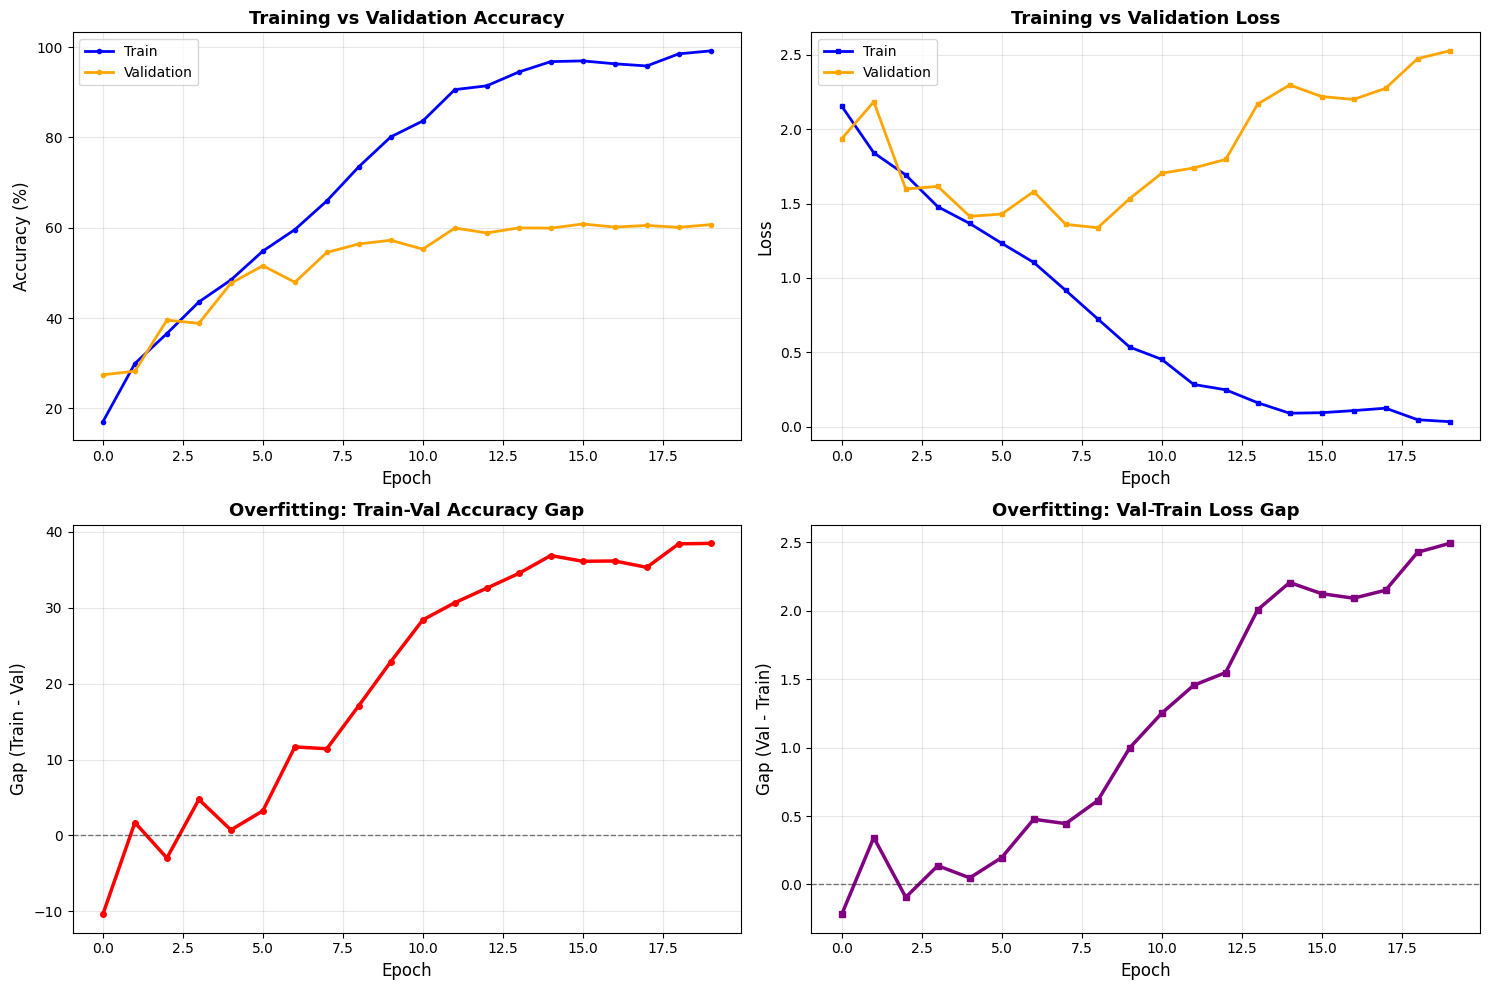

Final Train Accuracy: 99.16%
Final Val Accuracy:   60.68%
Final Test Accuracy:  54.60%
Train-Val Gap:        +38.48%
Train-Test Gap:       +44.56%

Final Train Loss:     0.0338
Final Val Loss:       2.5264
Loss Gap (Val-Train): +2.4926


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training Accuracy
axes[0, 0].plot(train_accs, label='Train', marker='o', markersize=3, linewidth=2, color='blue')
axes[0, 0].plot(val_accs, label='Validation', marker='o', markersize=3, linewidth=2, color='orange')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 0].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Training Loss
axes[0, 1].plot(train_losses, label='Train', marker='s', markersize=3, linewidth=2, color='blue')
axes[0, 1].plot(val_losses, label='Validation', marker='s', markersize=3, linewidth=2, color='orange')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Generalization Gap in Accuracy
gap_acc = [train - val for train, val in zip(train_accs, val_accs)]
axes[1, 0].plot(gap_acc, linewidth=2.5, marker='o', markersize=4, color='red')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Gap (Train - Val)', fontsize=12)
axes[1, 0].set_title('Overfitting: Train-Val Accuracy Gap', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)

# Generalization Gap in Loss
gap_loss = [val - train for train, val in zip(train_losses, val_losses)]
axes[1, 1].plot(gap_loss, linewidth=2.5, marker='s', markersize=4, color='purple')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Gap (Val - Train)', fontsize=12)
axes[1, 1].set_title('Overfitting: Val-Train Loss Gap', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()


# Printing final metrics

print(f"Final Train Accuracy: {train_accs[-1]:.2f}%")
print(f"Final Val Accuracy:   {val_accs[-1]:.2f}%")
print(f"Final Test Accuracy:  {test_acc:.2f}%")
print(f"Train-Val Gap:        {train_accs[-1] - val_accs[-1]:+.2f}%")
print(f"Train-Test Gap:       {train_accs[-1] - test_acc:+.2f}%")
print(f"\nFinal Train Loss:     {train_losses[-1]:.4f}")
print(f"Final Val Loss:       {val_losses[-1]:.4f}")
print(f"Loss Gap (Val-Train): {val_losses[-1] - train_losses[-1]:+.4f}")

As we can see, the generalization gap starts to increase after epoch 5, as training loss continues to decrease until 0 and validation loss skyrockets. This is clear sign of overfitting via increase of variance (sensitivity of model to data).

## 2.2 Verfying model confidence

When we are dealing with a classification task, models output probability scores for each class. If our model learns to distinguish classes, it has to have the capability to separate ambiguous cases, meaning, if making mistakes is not problematic, but making mistakes with high confidence is one of the main signs of overfitting or poor calibration.

In [ ]:
# Function for extracting probabilities from softmax layer
def get_confidences(loader):
      model.eval()
      correct_conf = []
      wrong_conf = []

      with torch.no_grad():
          for images, labels in loader:
              images, labels = images.to(device), labels.to(device)
              outputs = model(images)
              probs = F.softmax(outputs, dim=1)
              max_probs, preds = torch.max(probs, 1)

              # Separate by correctness
              correct_mask = (preds == labels)
              correct_conf.extend(max_probs[correct_mask].cpu().numpy())
              wrong_conf.extend(max_probs[~correct_mask].cpu().numpy())

      return correct_conf, wrong_conf

train_correct, train_wrong = get_confidences(train_loader)
test_correct, test_wrong = get_confidences(test_loader)

We can visualize the values as histograms and color cases of wrong and correct predictions

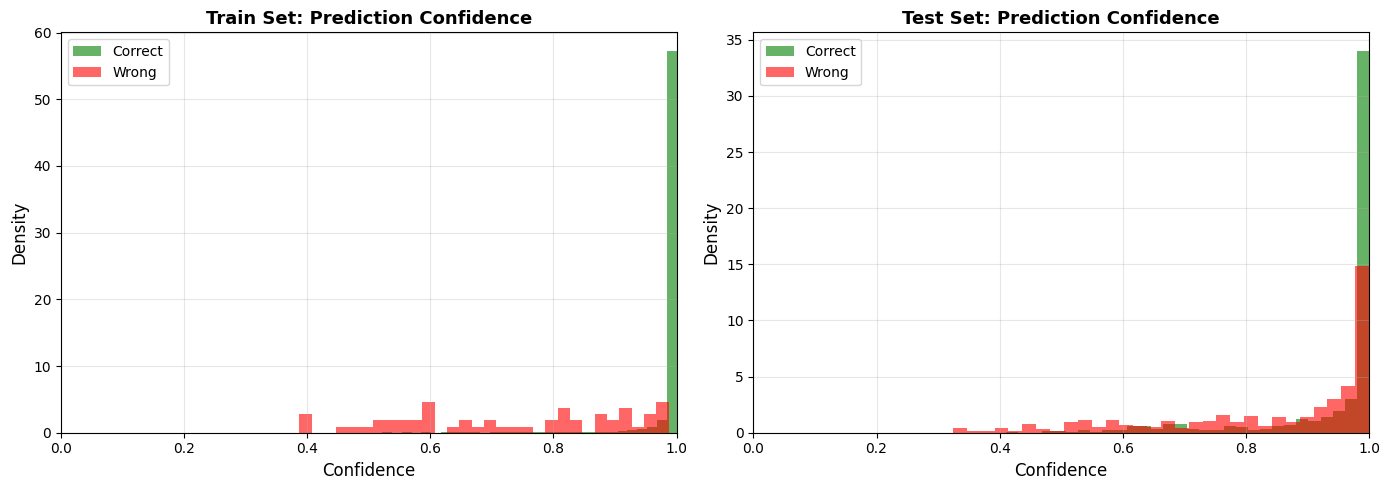

Train Set:
  Correct - Avg confidence: 0.990

Test Set:
  Correct - Avg confidence: 0.940
  Wrong   - Avg confidence: 0.844
    Test wrong avg: 0.844



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set confidence
axes[0].hist(train_correct, bins=30, alpha=0.6, label='Correct', color='green', density=True)
if len(train_wrong) > 0:
    axes[0].hist(train_wrong, bins=30, alpha=0.6, label='Wrong', color='red', density=True)
axes[0].set_xlabel('Confidence', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Train Set: Prediction Confidence', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])

# Test set confidence
axes[1].hist(test_correct, bins=30, alpha=0.6, label='Correct', color='green', density=True)
axes[1].hist(test_wrong, bins=30, alpha=0.6, label='Wrong', color='red', density=True)
axes[1].set_xlabel('Confidence', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Test Set: Prediction Confidence', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()

# printingh stats
print(f"Train Set:")
print(f"  Correct - Avg confidence: {np.mean(train_correct):.3f}")
print(f"\nTest Set:")
print(f"  Correct - Avg confidence: {np.mean(test_correct):.3f}")
print(f"  Wrong   - Avg confidence: {np.mean(test_wrong):.3f}")
print(f"    Test wrong avg: {np.mean(test_wrong):.3f}")
print(f"{'='*60}\n")



The test set confidence values show that in most of the cases, model was confident about the prediction which was not correct. This means that the model has discovered a "learned" pattern from training images (automobile outline) and believes that it exists in the current image (legs of frog).

## 2.3. GradCAM

We discussed that focusing on the wrong points in images can result in misclassification. In 2017, R. R. Selvaraju et. al [2] introduced a GradCAM technique as a visual model explainability method.

**GradCAM** is a visualization technique for CNNs that uses the gradients of the target class with respect to the final convolutional feature maps to compute a class-specific heatmap.  It highlights which spatial regions most strongly influence the model's prediction. We target the last convolutional layer (conv3) to see high-level features.

### Let's Initialize GradCAM to visualize what the CNN focuses on.

In [ ]:
def setup_gradcam(model):
    # Capturing last conv layer which captures semantic features
    target_layers = [model.conv3]
    cam = GradCAM(model=model, target_layers=target_layers)
    return cam

Following function demonstrates how to construct values for a heatmap with necessary comments:

In [ ]:
def collect_gradcam_samples(model, data_loader, device, num_samples=6):
    """
    Collect images and generate GradCAM heatmaps showing where the model "looks" and returns, original images,
    true labels, predicted labels, GradCAM visualizations

     Parameters
    ----------
    model : torch.nn.Module Trained PyTorch model to explain.
    data_loader : torch.utils.data.DataLoader: A dataloader providing images and labels (e.g. val or test loader).
    device : str or torch.device: Computation device ("cpu" or "cuda").
    num_samples : int, optional (default=6): Maximum number of samples to visualize.

    Returns
    -------
    images_list : list of np.ndarray: Original images (denormalized, RGB, shape= HxWx3).
    labels_list : list of int: Ground truth class labels for each sample.
    preds_list : list of int: Model predictions for each sample.
    heatmaps_list : list of np.ndarray: GradCAM overlay visualizations for each sample.
    """
    model.eval()
    cam = setup_gradcam(model)

    images_list = []
    labels_list = []
    preds_list = []
    heatmaps_list = []

    # We loop in data_loader and feed images and labels inside of the loop
    for images, labels in data_loader:
        images, labels = images.to(device), labels.to(device)

        # Getting model predictions
        with torch.no_grad():
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

        # Process each image
        for i in range(min(num_samples, images.size(0))):
            img_tensor = images[i]

            # Generate GradCAM heatmap
            cam_input = img_tensor.unsqueeze(0)
            grayscale_cam = cam(input_tensor=cam_input, targets=None)
            grayscale_cam = grayscale_cam[0, :]

            # Prepare image for visualization
            img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
            mean = np.array([0.4914, 0.4822, 0.4465])
            std = np.array([0.2470, 0.2435, 0.2616])
            img_np = img_np * std + mean
            img_np = np.clip(img_np, 0, 1)

            # Overlay heatmap on image
            visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

            # Store results
            images_list.append(img_np)
            heatmaps_list.append(visualization)
            labels_list.append(labels[i].item())
            preds_list.append(preds[i].item())

            if len(images_list) >= num_samples:
                break

        if len(images_list) >= num_samples:
            break

    # Cleanup
    del cam
    torch.cuda.empty_cache()

    return images_list, labels_list, preds_list, heatmaps_list

Let's visualize the most important points from the perspective of the model:

In [ ]:
def visualize_gradcam_results(images_list, labels_list, preds_list, heatmaps_list,
                             class_names, title="GradCAM"):
    """
    This function is written by Claude, the prompt was:

    How to create a visualization grid showing:
    - Top row: Original images with true/predicted labels
    - Bottom row: GradCAM attention heatmaps
    """

    num_samples = len(images_list)

    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    fig.suptitle(f'{title} - What Does the Model Focus On?',
                 fontsize=14, fontweight='bold')


    for i in range(num_samples):
        # Top row: Original image with labels
        axes[0, i].imshow(images_list[i])
        axes[0, i].axis('off')

        true_label = class_names[labels_list[i]]
        pred_label = class_names[preds_list[i]]
        correct = "✓" if labels_list[i] == preds_list[i] else "✗"
        color = 'green' if labels_list[i] == preds_list[i] else 'red'

        axes[0, i].set_title(f'True: {true_label}\nPred: {pred_label} {correct}',
                            fontsize=9, color=color)

        # Bottom row: Attention heatmap
        axes[1, i].imshow(heatmaps_list[i])
        axes[1, i].axis('off')
        axes[1, i].set_title('Attention Map', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'gradcam_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

Calling the functions we defined:

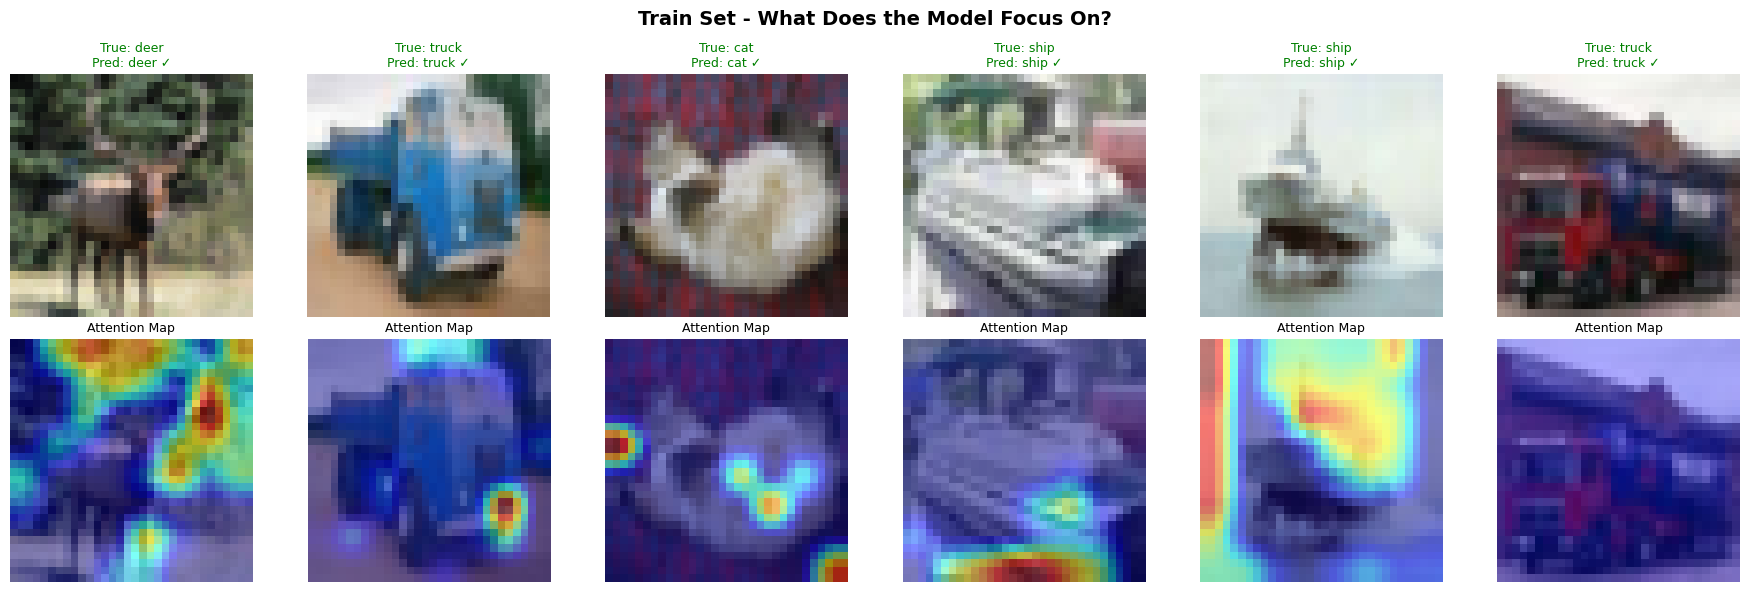

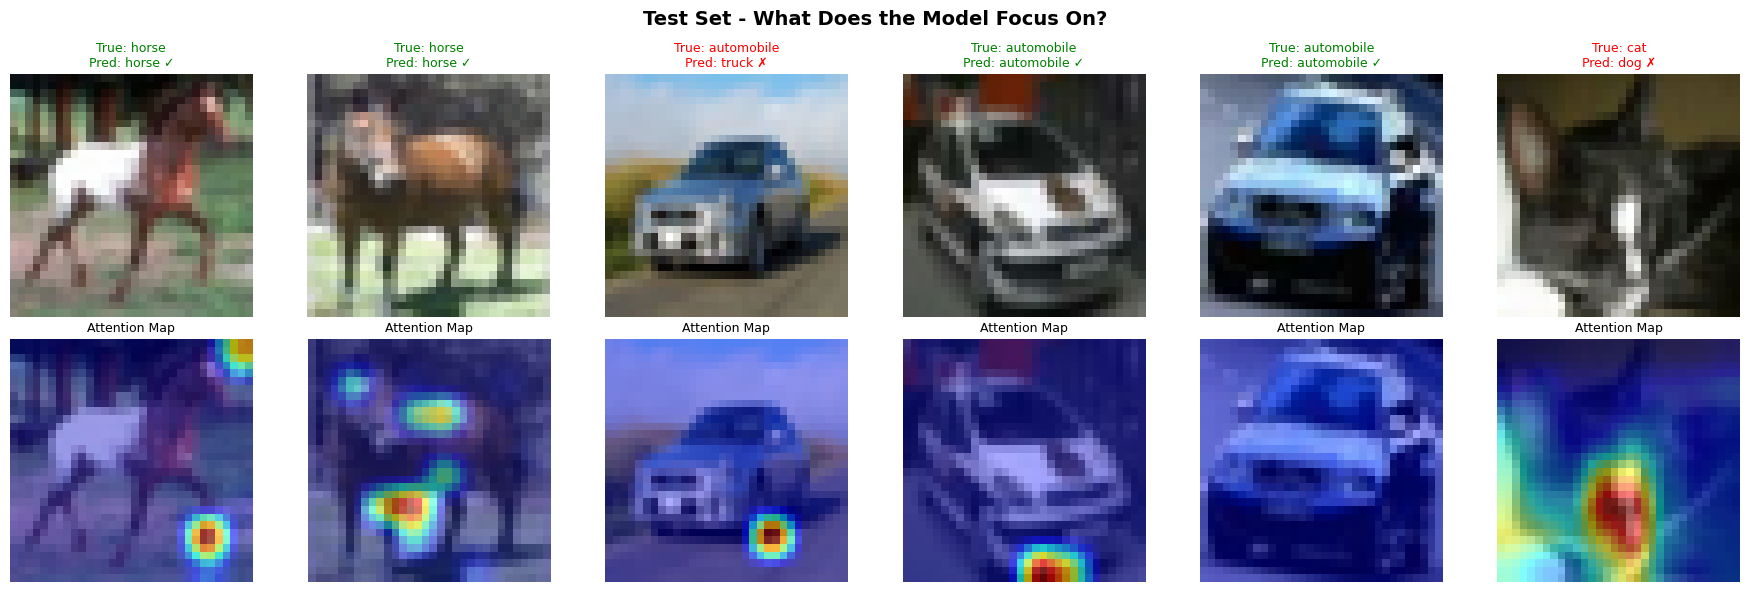

In [ ]:
train_imgs, train_labels, train_preds, train_heatmaps = collect_gradcam_samples(model, train_loader, device, num_samples=6)

visualize_gradcam_results(train_imgs, train_labels, train_preds, train_heatmaps, class_names, title="Train Set")
test_imgs, test_labels, test_preds, test_heatmaps = collect_gradcam_samples(model, test_loader, device, num_samples=6)

visualize_gradcam_results(test_imgs, test_labels, test_preds, test_heatmaps, class_names, title="Test Set")

This is a great way of visually diagnosing the model. We can see in the test set, the model focuses completely on unrelated parts of the image (e.g, background) as we discussed in part 2.3

## 2.4 Random Label Sanity Test

Zhang et. al (2021) [3] designed a groundbreaking experiment. They flipped the labels of the dataset randomly to prove that the model can even memorize labels that have nothing to do with the image. This proved that Neural Networks have incredible potential for memorizing the training data, and even explicit regularization techniques might not ensure generalization.

Getting inspiration from the paper, I propose randomization of labels as a potential test. In this check, if the model has high accuracy, it means that it has enough capacity to learn even randomized labels, and we cannot trust the accuracy metrics.

In [ ]:
class CorruptedLabelsDataset(Dataset):
    """
    Wraps a dataset and corrupts a fixed fraction of labels.
    Returns images and new labels
    """
    def __init__(self, base_dataset, corruption_fraction=0.5, num_classes=10):
        self.base_dataset = base_dataset
        self.num_classes = num_classes

        # Extract all true labels once
        labels = []
        for i in range(len(base_dataset)):
            _, y = base_dataset[i]
            labels.append(int(y))
        self.labels = np.array(labels)

        # Decide which samples to corrupt
        num_to_corrupt = int(len(self.labels) * corruption_fraction)
        corrupt_indices = np.random.choice(len(self.labels), num_to_corrupt, replace=False)

        for idx in corrupt_indices:
            true_label = self.labels[idx]
            wrong_labels = [l for l in range(num_classes) if l != true_label]
            self.labels[idx] = np.random.choice(wrong_labels)

        self.corrupted_indices = set(corrupt_indices)
        print(
            f"Corrupting {len(self.corrupted_indices)} out of {len(self.labels)} labels "
            f"({corruption_fraction*100:.0f}%)")

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, _ = self.base_dataset[idx]   # ignore original label
        corrupted_or_true_label = int(self.labels[idx])
        return image, corrupted_or_true_label


Let's randomize 50% of the labels and observe if the model can memorize them

In [ ]:
# Let's get small subset for faster training
train_dataset_clean = get_subset(train_dataset_full, fraction=0.1)

# Corrupt 50% of labels
train_dataset_corrupted = CorruptedLabelsDataset(train_dataset_clean, corruption_fraction=0.5, num_classes=num_classes)

# Create loader
train_loader_corrupted = DataLoader(train_dataset_corrupted, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

Corrupting 2500 out of 5000 labels (50%)


Training on 50% corrupted labels

In [ ]:
model_corrupted, corrupt_train_accs, corrupt_val_accs, corrupt_train_losses, corrupt_val_losses = train_model(
    train_loader_corrupted, val_loader, num_classes, device, num_epochs=50)

# Evaluate on clean test set
test_acc_corrupted = evaluate_model(model_corrupted, test_loader, device)

Epoch 1: Train Acc=10.38%, Val Acc=16.14%, Train Loss=2.3026, Val Loss=2.2384
Epoch 5: Train Acc=16.36%, Val Acc=27.84%, Train Loss=2.2409, Val Loss=2.0384
Epoch 10: Train Acc=26.60%, Val Acc=35.42%, Train Loss=2.0864, Val Loss=1.8739
Epoch 15: Train Acc=55.36%, Val Acc=31.88%, Train Loss=1.2472, Val Loss=2.6803
Epoch 20: Train Acc=88.52%, Val Acc=27.40%, Train Loss=0.3568, Val Loss=4.9848
Epoch 25: Train Acc=96.30%, Val Acc=28.10%, Train Loss=0.1213, Val Loss=5.9235
Epoch 30: Train Acc=98.90%, Val Acc=27.76%, Train Loss=0.0410, Val Loss=7.5172
Epoch 35: Train Acc=98.08%, Val Acc=28.68%, Train Loss=0.0562, Val Loss=7.4652
Epoch 40: Train Acc=95.08%, Val Acc=28.28%, Train Loss=0.1659, Val Loss=5.9551
Epoch 45: Train Acc=100.00%, Val Acc=28.46%, Train Loss=0.0007, Val Loss=9.0779
Epoch 50: Train Acc=100.00%, Val Acc=28.96%, Train Loss=0.0000, Val Loss=12.3940
Final Test Accuracy: 25.80%


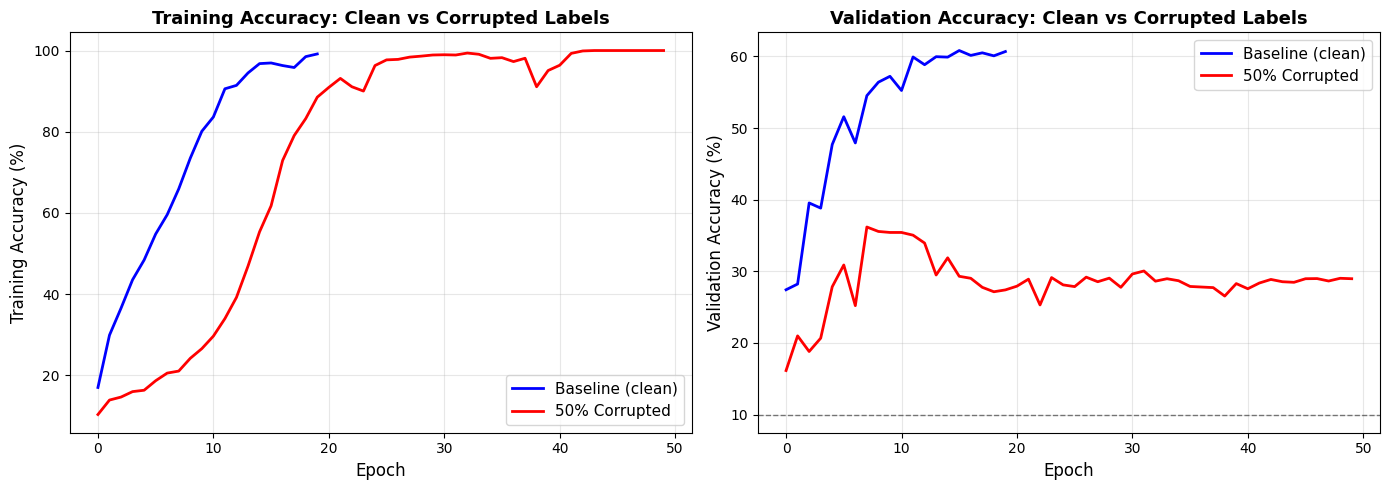

In [ ]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training accuracy
axes[0].plot(train_accs, label='Baseline (clean)', linewidth=2, color='blue')
axes[0].plot(corrupt_train_accs, label='50% Corrupted', linewidth=2, color='red')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Accuracy (%)', fontsize=12)
axes[0].set_title('Training Accuracy: Clean vs Corrupted Labels', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Validation accuracy
axes[1].plot(val_accs, label='Baseline (clean)', linewidth=2, color='blue')
axes[1].plot(corrupt_val_accs, label='50% Corrupted', linewidth=2, color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[1].set_title('Validation Accuracy: Clean vs Corrupted Labels', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=10, color='black', linestyle='--', alpha=0.5, linewidth=1,label='Random chance (10%)')

plt.tight_layout()
plt.show()
plt.close()

The model was able to memorize all dataset, although we randomly flipped the labels in half of the dataset. This check can be used to understand model capacity. Expected behaviour in optimal models would be disregarding of noise and close to 50% accuracy on the training dataset.

## 2.5 Weight Distribution

Just one layer before our model makes a decision on which class has the highest probability, the learned features from images directly represent the internal representation or “understanding” the model has developed. By extracting these **penultimate layer features**, we can analyze how well different classes are separated in train and validation tests.

In [ ]:
def extract_features(model, data_loader, device):
    """Function for extracting -1 layer features"""
    model.eval()
    all_features, all_labels = [], []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            x = model.pool(F.relu(model.conv1(images)))
            x = model.pool(F.relu(model.conv2(x)))
            x = model.pool(F.relu(model.conv3(x)))
            x = model.pool(F.relu(model.conv4(x)))
            x = x.view(x.size(0), -1)
            features = F.relu(model.fc1(x))

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_features), np.concatenate(all_labels)

t-SNE is a technique that takes high-dimensional data compresses it into lower dimensions, so we can visualize it as a scatter plot. It tries to keep similar points close together, helping us see patterns and clusters.

In [ ]:
def compute_tsne(train_features, val_features):

    """Function to run t-SNE on combined features, returns resulting embedings as list"""
    all_features = np.vstack([train_features, val_features])
    n_train = len(train_features)

    # Let's reduce dimensionality to 2 for 2D scatter plotting
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings = tsne.fit_transform(all_features)

    return embeddings[:n_train], embeddings[n_train:]

The following function visualizes train and validation results after applying *t-SNE* to penultimate layer features.

In [ ]:
def visualize_tsne(train_emb, train_labels, val_emb, val_labels, class_names):
    """ Plotting function for t-SNE """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

    # Train plot
    for i in range(len(class_names)):
        mask = (train_labels == i)
        if np.any(mask):
            axes[0].scatter(train_emb[mask, 0], train_emb[mask, 1], c=[colors[i]], s=40, alpha=0.7, label=class_names[i], edgecolors='white', linewidths=0.5)
    axes[0].set_title('Train Set Features', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('t-SNE 1', fontsize=11)
    axes[0].set_ylabel('t-SNE 2', fontsize=11)
    axes[0].legend(loc='best', fontsize=9, framealpha=0.9)
    axes[0].grid(True, alpha=0.2)

    # Validation plot
    for i in range(len(class_names)):
        mask = (val_labels == i)
        if np.any(mask):
            axes[1].scatter(val_emb[mask, 0], val_emb[mask, 1], c=[colors[i]], s=40, alpha=0.7, label=class_names[i], edgecolors='white', linewidths=0.5)
    axes[1].set_title('Validation Set Features', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('t-SNE 1', fontsize=11)
    axes[1].set_ylabel('t-SNE 2', fontsize=11)
    axes[1].legend(loc='best', fontsize=9, framealpha=0.9)
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

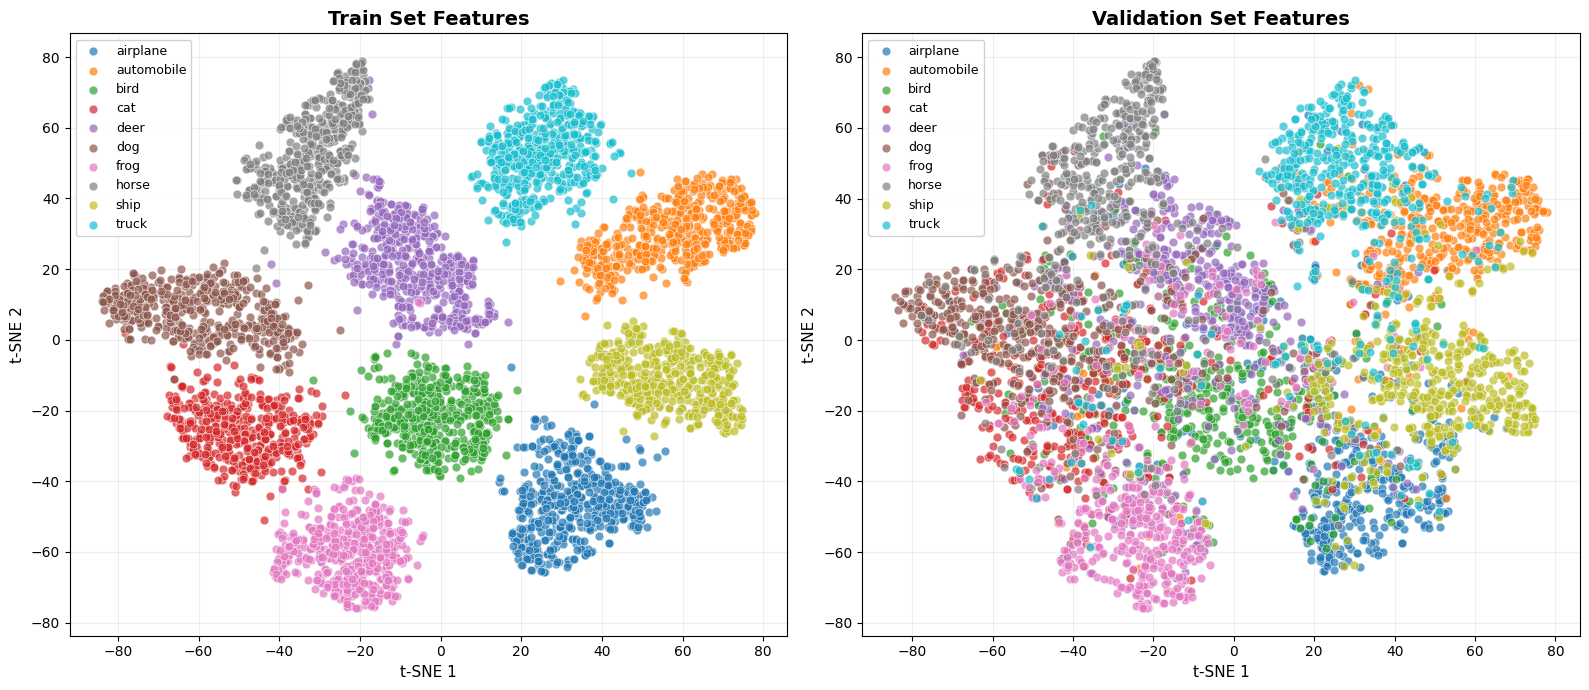

In [ ]:
# Extract features
train_features, train_labels = extract_features(model, train_loader, device)
val_features, val_labels = extract_features(model, val_loader, device)

# Run t-SNE
train_tsne, val_tsne = compute_tsne(train_features, val_features)

# Visualize
visualize_tsne(train_tsne, train_labels, val_tsne, val_labels, class_names)

The visualization clearly indicates that almost all classes are easily separated in the training set. However, when we apply this "learning" to the test set, we observe that the model confuses not only similar classes (airplane and automobile) but also distinct classes (cat, frog, deer, etc.) with each other.

***Thanks for going through this workflow. Make sure to check your models thoroughly and stay safe!***

-------------------------------------------------------

# References

1. Krizhevsky, Alex. (2012). Learning Multiple Layers of Features from Tiny Images. University of Toronto.
2. R. R. Selvaraju, M. Cogswell, A. Das, R. Vedantam, D. Parikh and D. Batra, "Grad-CAM: Visual Explanations from Deep Networks via Gradient-Based Localization," 2017 IEEE International Conference on Computer Vision (ICCV), Venice, Italy, 2017, pp. 618-626, doi: 10.1109/ICCV.2017.74.
3. Chiyuan Zhang, Samy Bengio, Moritz Hardt, Benjamin Recht, and Oriol Vinyals. 2021. Understanding deep learning (still) requires rethinking generalization. Commun. ACM 64, 3 (March 2021), 107–115. https://doi.org/10.1145/3446776

---------------------------------------------------------------------------------

# About the Author

<h2 align="center">Howdy, I'm Dursun 👋</h2>

I am currently a PhD student in the Petroleum & Geosystems Engineering Department at UT Austin, co-supervised by [Dr. Michael Pyrcz](https://michaelpyrcz.com/) and [Dr. John T. Foster](https://johnfoster.pge.utexas.edu/).

- 🔬 I'm passionate about bridging subsurface data and AI, developing data-driven solutions for real-world challenges
- My research focuses on geostatistics & explainable machine learning models for subsurface description and reservoir management
- I also love playing around with images and building computer vision models
- 📫 You can reach me at **dursun.dashdamirov@utexas.edu**  


<h3 align="left">You can also find me in</h3>
<p align="left">

<!--
  Thanks to https://github.com/rahuldkjain and Wikipedia for the social media and tech icon assets used in this README.
-->

<a href="https://github.com/DDursun" target="_blank"><img align="center" src="https://raw.githubusercontent.com/rahuldkjain/github-profile-readme-generator/master/src/images/icons/Social/github.svg" alt="github" height="30" width="40" /></a>
<a href="https://www.linkedin.com/in/dursun-dashdamirov/" target="blank"><img align="center" src="https://raw.githubusercontent.com/rahuldkjain/github-profile-readme-generator/master/src/images/icons/Social/linked-in-alt.svg" alt="https://www.linkedin.com/in/dursun-dashdamirov/" height="30" width="40" /></a>
<a href="https://scholar.google.com/citations?user=jn2u55MAAAAJ&hl=en&oi=ao" target="_blank">
  <img align="center" src="https://upload.wikimedia.org/wikipedia/commons/c/c7/Google_Scholar_logo.svg" alt="Google Scholar" height="30" width="40" /></a>
<a href="https://kaggle.com/dursundashdamirov" target="blank"><img align="center" src="https://raw.githubusercontent.com/rahuldkjain/github-profile-readme-generator/master/src/images/icons/Social/kaggle.svg" alt="dursundashdamirov" height="30" width="40" /></a>
<a href="https://medium.com/@dashdamirov" target="blank"><img align="center" src="https://raw.githubusercontent.com/rahuldkjain/github-profile-readme-generator/master/src/images/icons/Social/medium.svg" alt="@dashdamirov" height="30" width="40" /></a>
<a href="https://www.hackerrank.com/d_dursun" target="blank"><img align="center" src="https://raw.githubusercontent.com/rahuldkjain/github-profile-readme-generator/master/src/images/icons/Social/hackerrank.svg" alt="d_dursun" height="30" width="40" /></a>
</p>

<h3 align="left">Languages and Tools:</h3>
<p align="left"> <a href="https://www.w3schools.com/cs/" target="_blank" rel="noreferrer"> <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/csharp/csharp-original.svg" alt="csharp" width="40" height="40"/> </a> <a href="https://dotnet.microsoft.com/" target="_blank" rel="noreferrer"> <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/dot-net/dot-net-original-wordmark.svg" alt="dotnet" width="40" height="40"/> </a> <a href="https://git-scm.com/" target="_blank" rel="noreferrer"> <img src="https://www.vectorlogo.zone/logos/git-scm/git-scm-icon.svg" alt="git" width="40" height="40"/> </a> <a href="https://www.microsoft.com/en-us/sql-server" target="_blank" rel="noreferrer"> <img src="https://www.svgrepo.com/show/303229/microsoft-sql-server-logo.svg" alt="mssql" width="40" height="40"/> </a> <a href="https://www.oracle.com/" target="_blank" rel="noreferrer"> <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/oracle/oracle-original.svg" alt="oracle" width="40" height="40"/> </a> <a href="https://pandas.pydata.org/" target="_blank" rel="noreferrer"> <img src="https://raw.githubusercontent.com/devicons/devicon/2ae2a900d2f041da66e950e4d48052658d850630/icons/pandas/pandas-original.svg" alt="pandas" width="40" height="40"/> </a> <a href="https://www.python.org" target="_blank" rel="noreferrer"> <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" alt="python" width="40" height="40"/> </a> <a href="https://pytorch.org/" target="_blank" rel="noreferrer"> <img src="https://www.vectorlogo.zone/logos/pytorch/pytorch-icon.svg" alt="pytorch" width="40" height="40"/> </a> <a href="https://scikit-learn.org/" target="_blank" rel="noreferrer"> <img src="https://upload.wikimedia.org/wikipedia/commons/0/05/Scikit_learn_logo_small.svg" alt="scikit_learn" width="40" height="40"/> </a> <a href="https://seaborn.pydata.org/" target="_blank" rel="noreferrer"> <img src="https://seaborn.pydata.org/_images/logo-mark-lightbg.svg" alt="seaborn" width="40" height="40"/> </a> <a href="https://www.tensorflow.org" target="_blank" rel="noreferrer"> <img src="https://www.vectorlogo.zone/logos/tensorflow/tensorflow-icon.svg" alt="tensorflow" width="40" height="40"/> </a> </p>


---------------------------------------------------------------------------------

# About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences.

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you!

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)